# Alerta 1 (Origen Monetario): preparación de variables y etiqueta objetivo

Este notebook se limita a la **Fase 1** de la TACE: distorsión nominal.

Objetivos en esta etapa:
- Usar solo variables de origen monetario: `FEDFUNDS`, `GS10` y su spread (`GS10 - FEDFUNDS`).
- Construir la etiqueta de crisis híbrida (`Y`) con dos criterios:
  - Recesión oficial NBER.
  - Variación interanual de `GDPC1` menor o igual a 0.
- Aplicar horizonte predictivo de 18 meses (`shift(-18)` de la etiqueta actual).
- Homologar todas las series al mismo rango temporal: **1980-01-01 a 2025-10-01**.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

sns.set_theme(style='whitegrid')

# Ventana temporal única del proyecto
START_DATE = '1980-01-01'
END_DATE = '2025-10-01'
TARGET_SHIFT_MONTHS = 18

DATA_DIR = Path('datos ABCT')

# Recesiones NBER (base oficial). Se expresa en frecuencia mensual.
NBER_PERIODS = [
    ('1980-01-01', '1980-07-01'),
    ('1981-07-01', '1982-11-01'),
    ('1990-07-01', '1991-03-01'),
    ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'),
    ('2020-02-01', '2020-04-01'),
]

In [2]:
def load_series(csv_path: Path, value_col: str, date_col: str = 'observation_date') -> pd.Series:
    """Carga una serie y la devuelve indexada por fecha (inicio de mes)."""
    df = pd.read_csv(csv_path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df[[date_col, value_col]].dropna()
    df = df.rename(columns={date_col: 'date', value_col: value_col.lower()})
    df = df.set_index('date').sort_index()

    # Normalizamos a inicio de mes para merge robusto entre series.
    df.index = df.index.to_period('M').to_timestamp(how='start')
    return df[value_col.lower()]


def monthly_interpolate_from_quarterly(series_q: pd.Series, start: str, end: str) -> pd.Series:
    """Convierte trimestral->mensual usando interpolación lineal."""
    monthly_idx = pd.date_range(start=start, end=end, freq='MS')
    series_m = series_q.reindex(monthly_idx).interpolate(method='linear')
    return series_m


# Series de Alerta 1 (origen monetario)
fedfunds = load_series(DATA_DIR / 'FEDFUNDS - mensual - hasta 2026.csv', 'FEDFUNDS')
gs10 = load_series(DATA_DIR / 'GS10 - mensual - hasta 2026.csv', 'GS10')

# GDPC1 solo para construir la etiqueta Y híbrida (no como predictor de Alerta 1)
gdpc1_q = load_series(DATA_DIR / 'GDPC1 - trimestral - hasta 01oct2025.csv', 'GDPC1')
gdpc1_m = monthly_interpolate_from_quarterly(gdpc1_q, START_DATE, END_DATE)

# Reindex mensual común en el rango definido
monthly_index = pd.date_range(start=START_DATE, end=END_DATE, freq='MS')

base = pd.DataFrame(index=monthly_index)
base['fedfunds'] = fedfunds.reindex(monthly_index)
base['gs10'] = gs10.reindex(monthly_index)
base['gdpc1'] = gdpc1_m.reindex(monthly_index)

print('Rango final:', base.index.min().date(), '->', base.index.max().date())
print('Filas:', len(base))
base.head()

Rango final: 1980-01-01 -> 2025-10-01
Filas: 550


,fedfunds,gs10,gdpc1
1980-01-01,13.82,10.80,7341.557000
1980-02-01,14.13,12.41,7291.134333
1980-03-01,17.19,12.75,7240.711667
1980-04-01,17.61,11.47,7190.289000
1980-05-01,10.98,10.18,7187.440333


In [3]:
# Feature principal de Alerta 1: pendiente de la curva
base['spread_yield_curve'] = base['gs10'] - base['fedfunds']

# Criterio de crisis por actividad real (dato duro)
base['gdpc1_yoy_pct'] = base['gdpc1'].pct_change(12) * 100
base['crisis_gdpc1'] = (base['gdpc1_yoy_pct'] <= 0).astype(int)

# Criterio de crisis por NBER
base['crisis_nber'] = 0
for start, end in NBER_PERIODS:
    mask = (base.index >= pd.Timestamp(start)) & (base.index <= pd.Timestamp(end))
    base.loc[mask, 'crisis_nber'] = 1

# Etiqueta híbrida actual (t)
base['crisis_now'] = ((base['crisis_nber'] == 1) | (base['crisis_gdpc1'] == 1)).astype(int)

# Objetivo de predicción: crisis en t + 18 meses
base['y_crisis_t_plus_18m'] = base['crisis_now'].shift(-TARGET_SHIFT_MONTHS)

# Dataset de modelado para Alerta 1
model_df = base[['fedfunds', 'gs10', 'spread_yield_curve', 'y_crisis_t_plus_18m']].copy()
model_df = model_df.dropna()
model_df['y_crisis_t_plus_18m'] = model_df['y_crisis_t_plus_18m'].astype(int)

print('Muestras útiles (tras shift y NA drop):', len(model_df))
print('Distribución de Y:')
print(model_df['y_crisis_t_plus_18m'].value_counts(normalize=True).rename('proporcion'))

model_df.head()

Muestras útiles (tras shift y NA drop): 532
Distribución de Y:
y_crisis_t_plus_18m
0    0.866541
1    0.133459
Name: proporcion, dtype: float64


,fedfunds,gs10,spread_yield_curve,y_crisis_t_plus_18m
1980-01-01,13.82,10.80,-3.02,1
1980-02-01,14.13,12.41,-1.72,1
1980-03-01,17.19,12.75,-4.44,1
1980-04-01,17.61,11.47,-6.14,1
1980-05-01,10.98,10.18,-0.80,1


In [5]:
# Resumen estadístico de variables de Alerta 1
summary = model_df[['fedfunds', 'gs10', 'spread_yield_curve']].describe().T
summary

# Correlación simple con la Y adelantada 18 meses
corr_with_y = model_df.corr(numeric_only=True)['y_crisis_t_plus_18m'].sort_values(ascending=False)
corr_with_y

y_crisis_t_plus_18m    1.000000
fedfunds               0.317673
gs10                   0.157572
spread_yield_curve    -0.479713
Name: y_crisis_t_plus_18m, dtype: float64

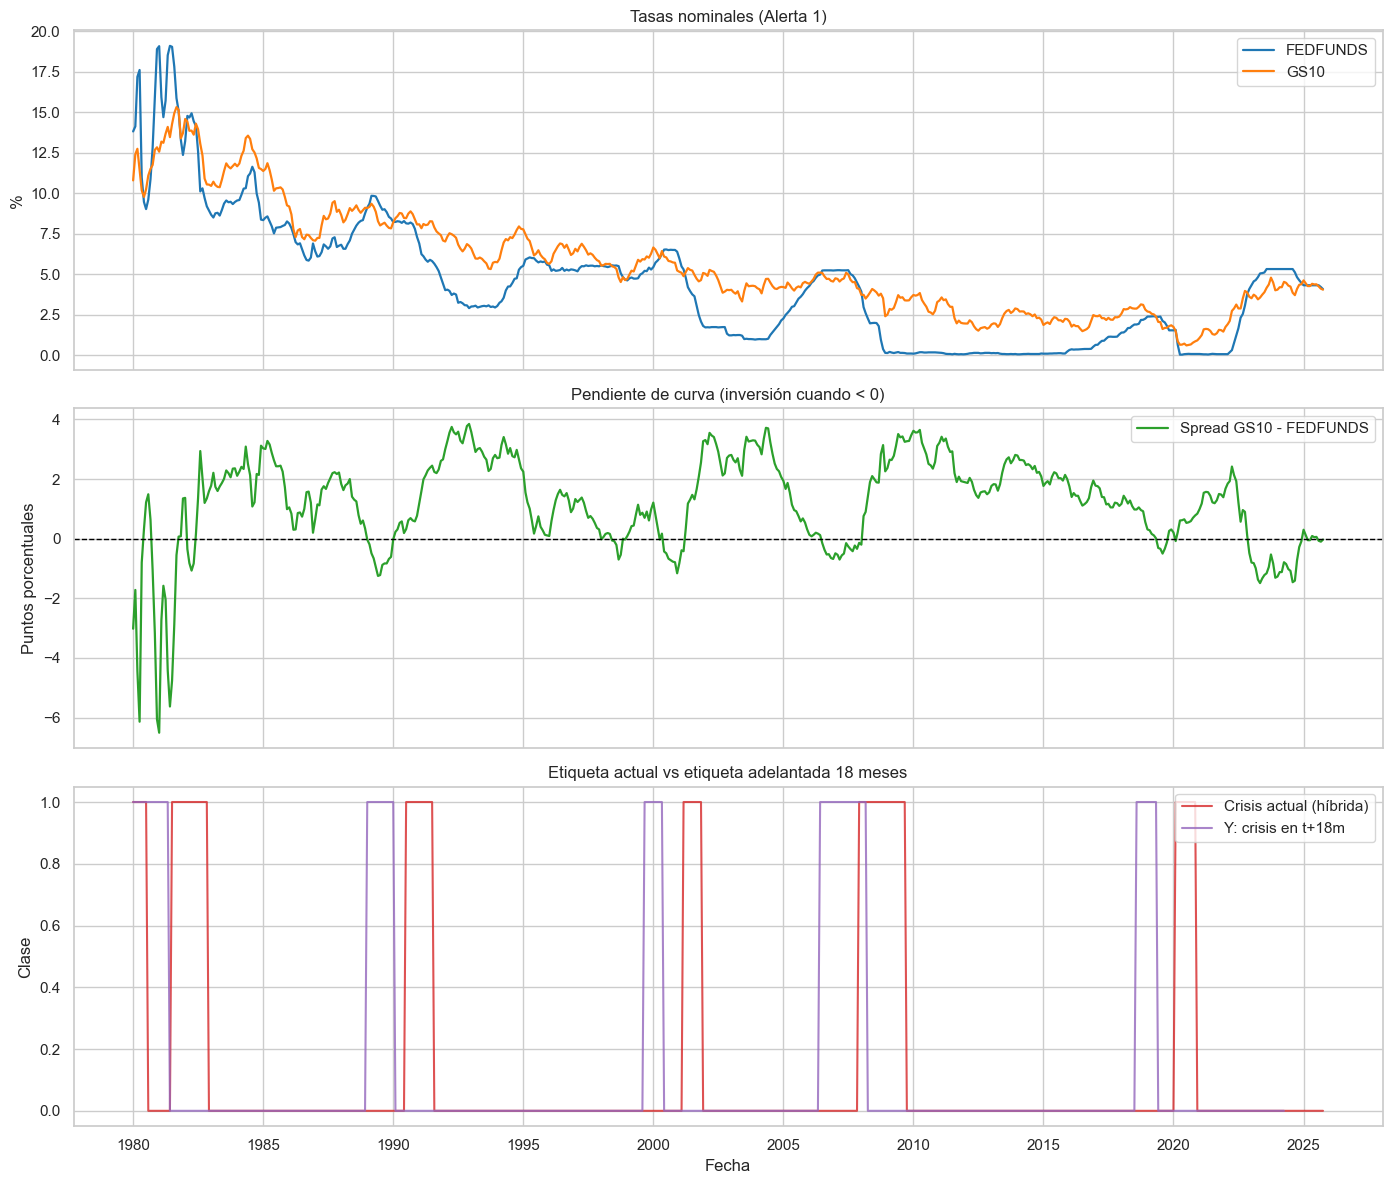

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(base.index, base['fedfunds'], label='FEDFUNDS', color='#1f77b4', linewidth=1.6)
axes[0].plot(base.index, base['gs10'], label='GS10', color='#ff7f0e', linewidth=1.6)
axes[0].set_title('Tasas nominales (Alerta 1)')
axes[0].set_ylabel('%')
axes[0].legend(loc='upper right')

axes[1].plot(base.index, base['spread_yield_curve'], label='Spread GS10 - FEDFUNDS', color='#2ca02c', linewidth=1.6)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Pendiente de curva (inversión cuando < 0)')
axes[1].set_ylabel('Puntos porcentuales')
axes[1].legend(loc='upper right')

axes[2].plot(base.index, base['crisis_now'], label='Crisis actual (híbrida)', color='#d62728', alpha=0.8)
axes[2].plot(base.index, base['y_crisis_t_plus_18m'], label='Y: crisis en t+18m', color='#9467bd', alpha=0.8)
axes[2].set_title('Etiqueta actual vs etiqueta adelantada 18 meses')
axes[2].set_ylabel('Clase')
axes[2].set_xlabel('Fecha')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

Variables originales:


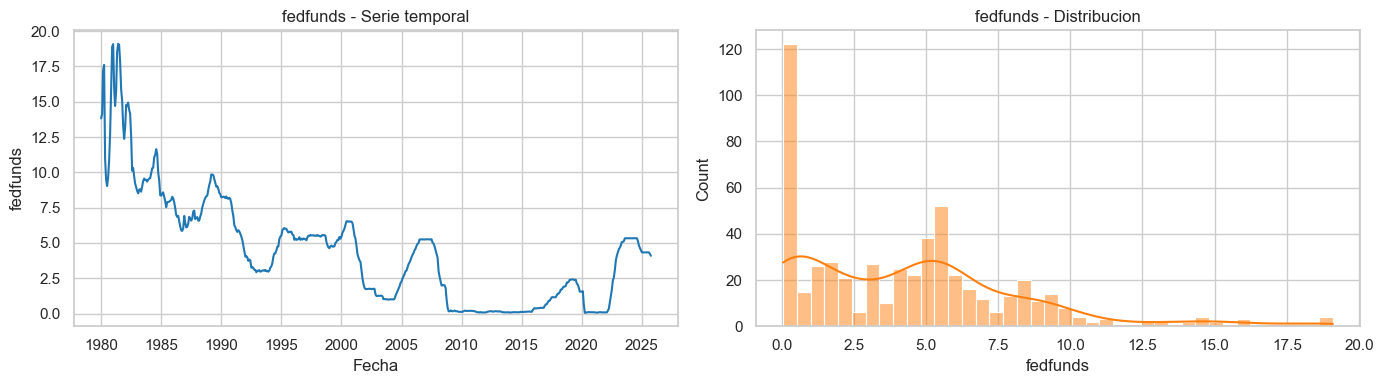

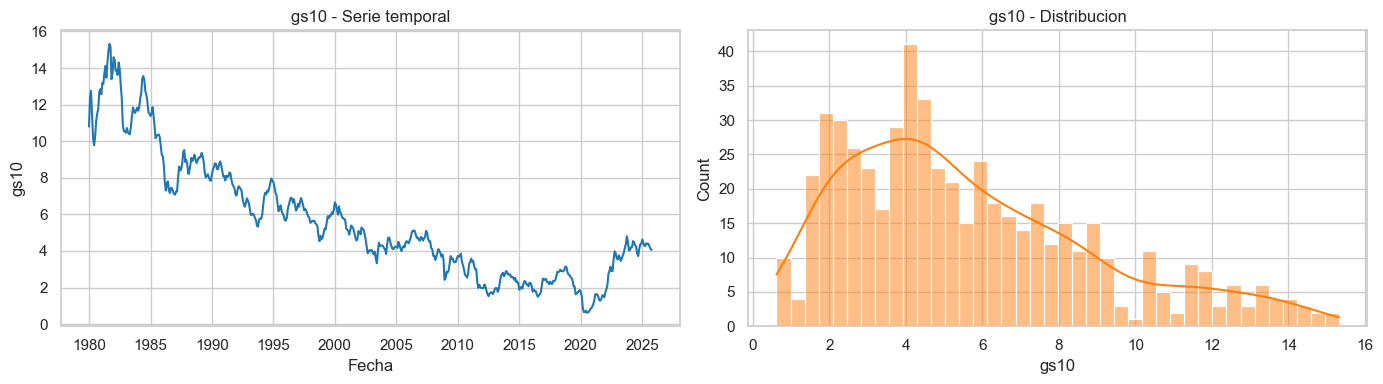

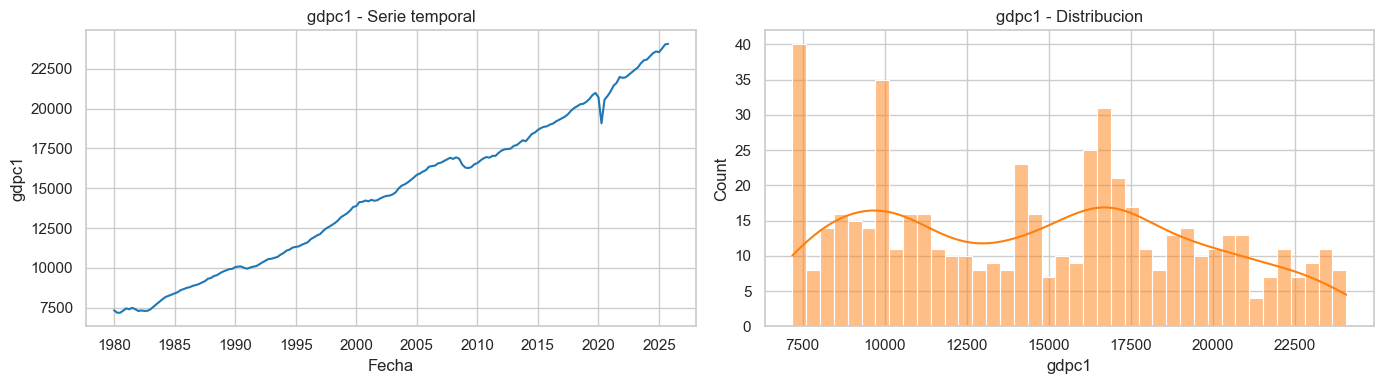

Variables definidas en Alerta 1:


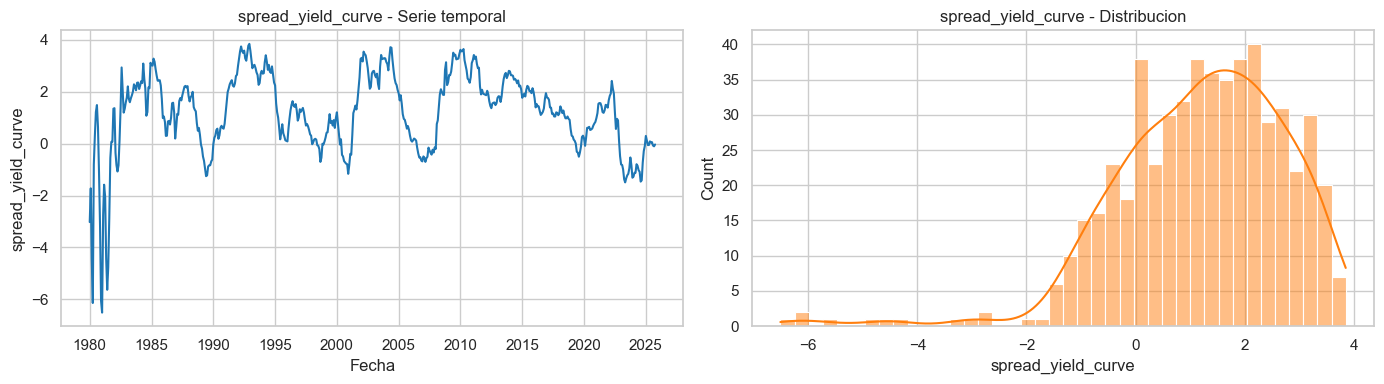

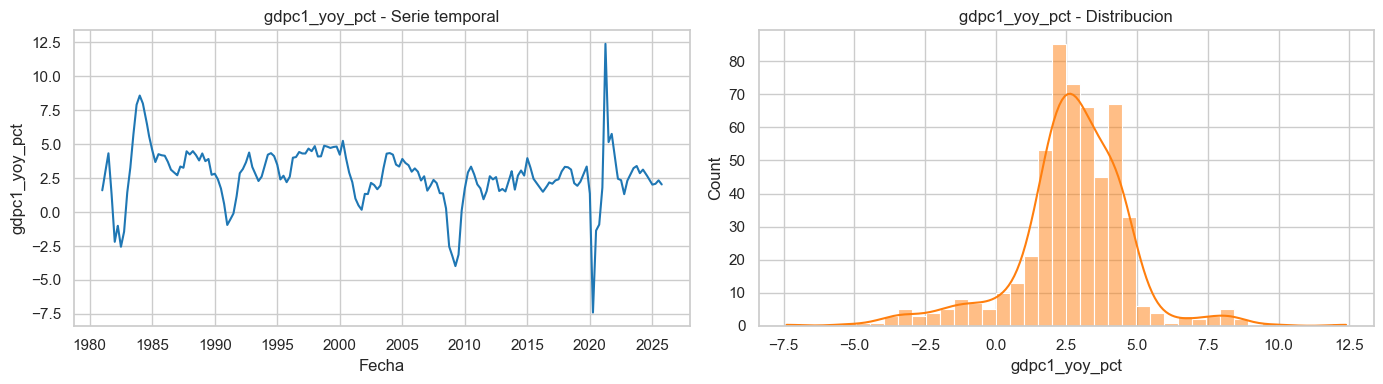

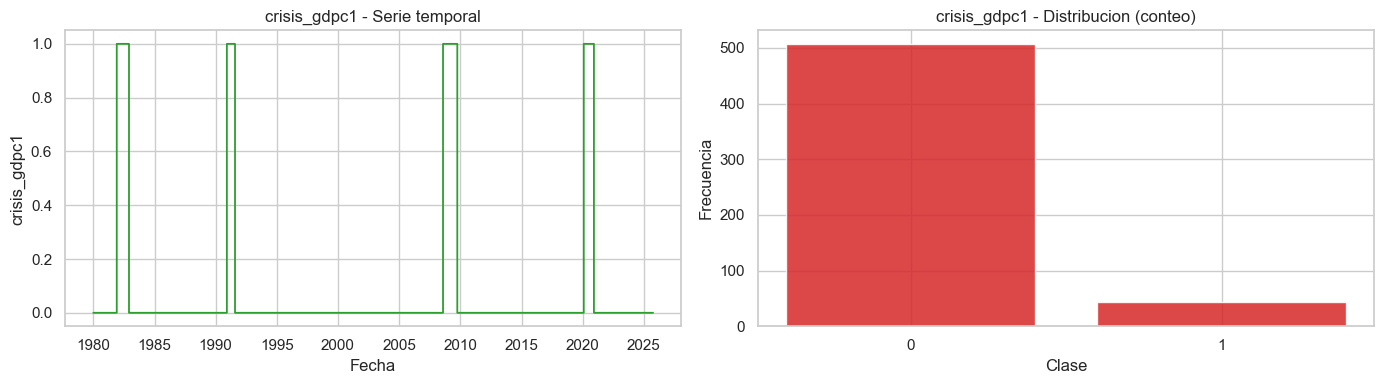

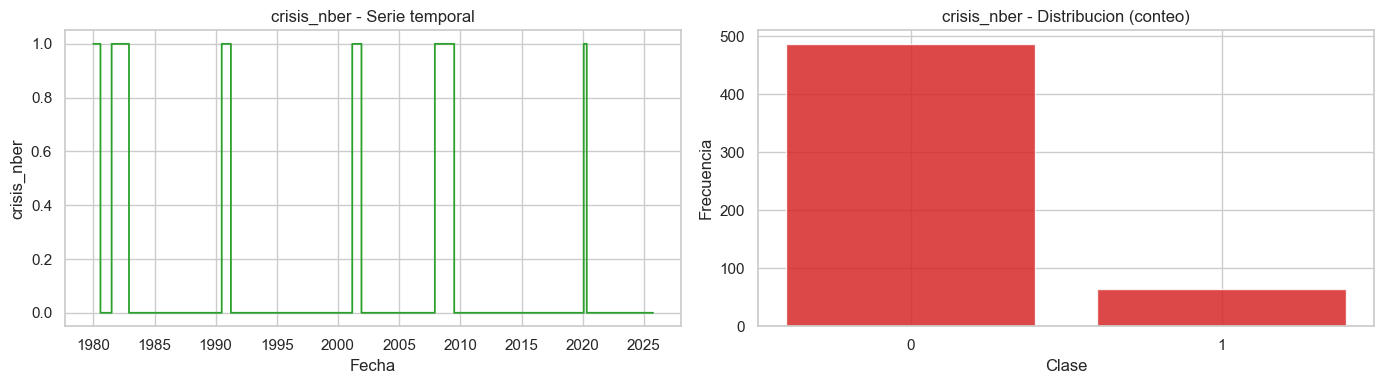

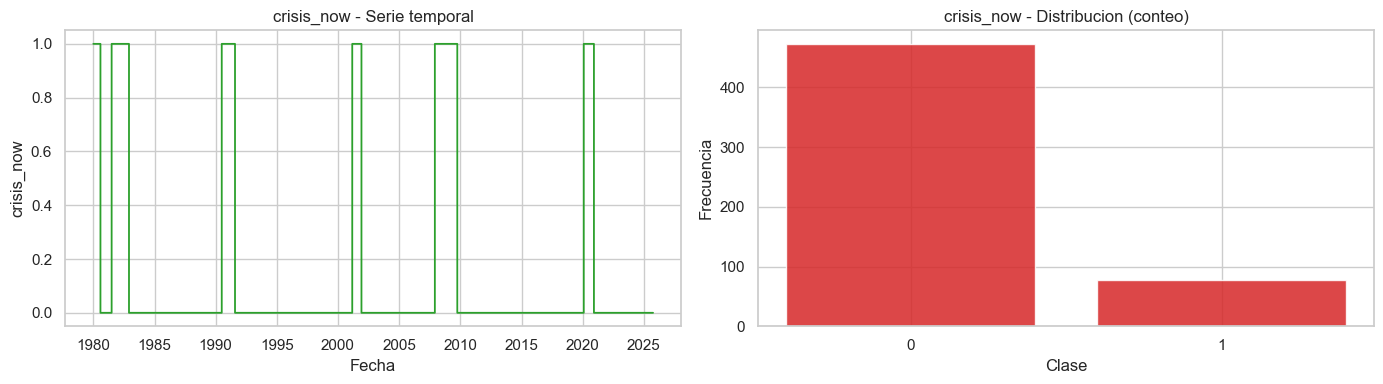

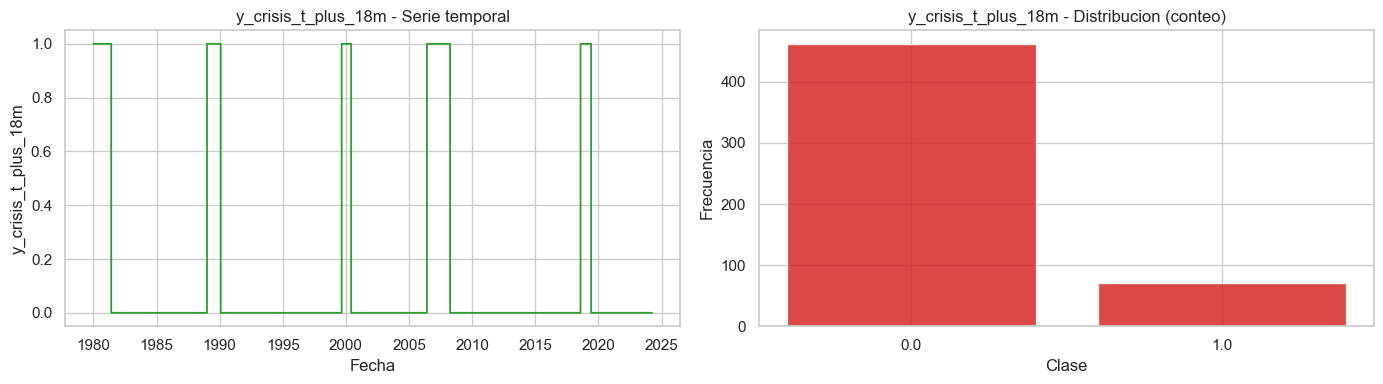

In [7]:
# Graficos individuales por variable (serie temporal + distribucion)
original_vars = ['fedfunds', 'gs10', 'gdpc1']
alert_defined_vars = ['spread_yield_curve', 'gdpc1_yoy_pct']
binary_vars = ['crisis_gdpc1', 'crisis_nber', 'crisis_now', 'y_crisis_t_plus_18m']


def plot_series_and_distribution(df: pd.DataFrame, columns: list[str], bins: int = 40) -> None:
    for col in columns:
        plot_df = df[[col]].dropna().copy()
        if plot_df.empty:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # Serie temporal individual
        axes[0].plot(plot_df.index, plot_df[col], color='#1f77b4', linewidth=1.5)
        axes[0].set_title(f'{col} - Serie temporal')
        axes[0].set_xlabel('Fecha')
        axes[0].set_ylabel(col)

        # Distribucion individual
        sns.histplot(plot_df[col], bins=bins, kde=True, ax=axes[1], color='#ff7f0e')
        axes[1].set_title(f'{col} - Distribucion')
        axes[1].set_xlabel(col)

        plt.tight_layout()
        plt.show()


print('Variables originales:')
plot_series_and_distribution(base, original_vars)

print('Variables definidas en Alerta 1:')
plot_series_and_distribution(base, alert_defined_vars)

# Para variables binarias, usamos barras de frecuencia para que la distribucion sea legible.
for col in binary_vars:
    plot_df = base[[col]].dropna().copy()
    if plot_df.empty:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].step(plot_df.index, plot_df[col], where='post', color='#2ca02c', linewidth=1.3)
    axes[0].set_title(f'{col} - Serie temporal')
    axes[0].set_xlabel('Fecha')
    axes[0].set_ylabel(col)
    axes[0].set_ylim(-0.05, 1.05)

    counts = plot_df[col].value_counts().sort_index()
    axes[1].bar(counts.index.astype(str), counts.values, color='#d62728', alpha=0.85)
    axes[1].set_title(f'{col} - Distribucion (conteo)')
    axes[1].set_xlabel('Clase')
    axes[1].set_ylabel('Frecuencia')

    plt.tight_layout()
    plt.show()

In [4]:
# Exportar features de Alerta 1 (sin Y: se reconstruye autoritativamente en modelo.ipynb)
output_path_1 = Path('dataset_alerta1.csv')
export_cols = ['fedfunds', 'gs10', 'spread_yield_curve']
model_df[export_cols].to_csv(output_path_1, index=True, index_label='date')
print('Archivo exportado:', output_path_1.resolve())
print('Columnas:', export_cols)
print('Filas:', len(model_df))

Archivo exportado: D:\Python Projects\crisis\dataset_alerta1.csv
Columnas: ['fedfunds', 'gs10', 'spread_yield_curve']
Filas: 532
